In [15]:
#Import Necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

In [3]:
#Loading Netflix dataset csv file
try:
    df = pd.read_csv("Netflix_dataset.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Dataset not found.")

Dataset loaded successfully.


In [5]:
# Check first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,23-Dec-16,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,20-Dec-18,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,16-Nov-17,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,1-Jan-20,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [7]:
# Check column names
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
#Check shape and size
df.shape

(7787, 12)

In [11]:
#Check for missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [13]:
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


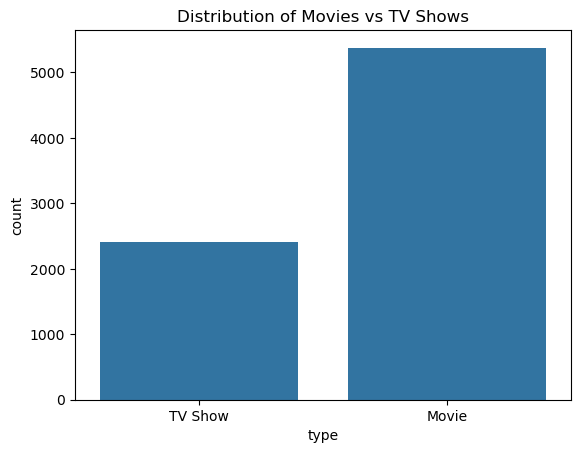

In [17]:
#Distribution of Movies vs TV Shows
df['type'].value_counts() #counting movies vs tv shows
sns.countplot(x='type', data=df) #visualization
plt.title('Distribution of Movies vs TV Shows')
plt.show()

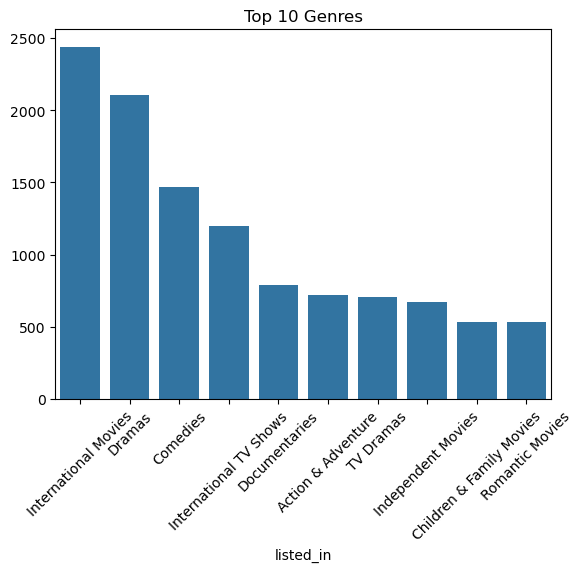

In [19]:
#Top Genre
# Splitting multiple genres in 'listed_in' columns
genre_series = df['listed_in'].str.split(',').explode().str.strip()
genre_series.value_counts().head(10)
#visualization
top_genres = genre_series.value_counts().head(10)
sns.barplot(x=top_genres.index, y=top_genres.values)
plt.title('Top 10 Genres')
plt.xticks(rotation=45)
plt.show()

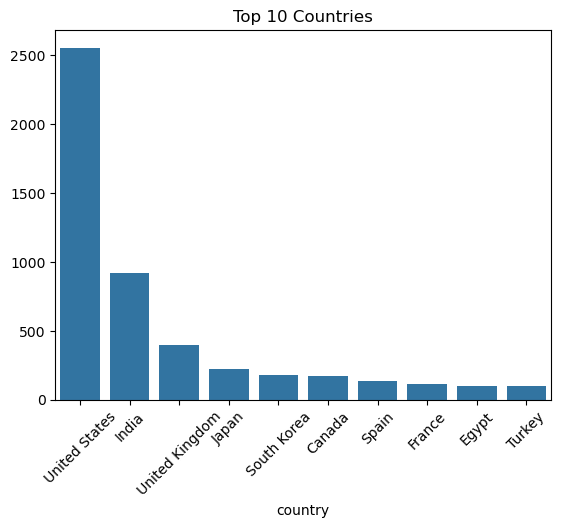

In [21]:
#Top Country
#top 10 countries by number of titles
df['country'].value_counts().head(10)
top_countries = df['country'].value_counts().head(10)
#visualization
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title('Top 10 Countries')
plt.xticks(rotation=45)
plt.show()

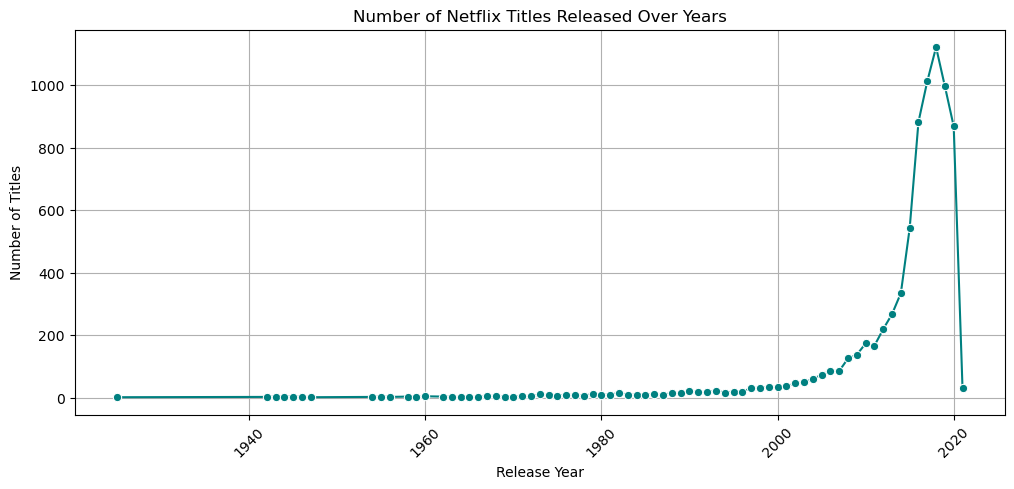

In [27]:
#Release Year
# Count number of titles per release year
titles_per_year = df['release_year'].value_counts().sort_index()

# Create line plot
plt.figure(figsize=(12,5))
sns.lineplot(x=titles_per_year.index, y=titles_per_year.values, marker='o', color='teal')
plt.title('Number of Netflix Titles Released Over Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [29]:
#Selecting important features
features = ['listed_in', 'country', 'release_year', 'type']
df[features].head()

,listed_in,country,release_year,type
0,"International TV Shows, TV Dramas, TV Sci-Fi &...",Brazil,2020,TV Show
1,"Dramas, International Movies",Mexico,2016,Movie
2,"Horror Movies, International Movies",Singapore,2011,Movie
3,"Action & Adventure, Independent Movies, Sci-Fi...",United States,2009,Movie
4,Dramas,United States,2008,Movie


In [31]:
#Cleaning and preprocessing the data
for feature in features:
    df[feature] = df[feature].fillna("Unknown").astype(str)

df[features].isnull().sum()

listed_in       0
country         0
release_year    0
type            0
dtype: int64

In [33]:
#Combining genre and country into one text column
df['combined_features'] = df['listed_in'] + " " + df['country']
df[['combined_features']].head()

,combined_features
0,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,"Dramas, International Movies Mexico"
2,"Horror Movies, International Movies Singapore"
3,"Action & Adventure, Independent Movies, Sci-Fi..."
4,Dramas United States


In [35]:
#Convert text into numerical vectors
tfidf = TfidfVectorizer(stop_words='english')
feature_vectors = tfidf.fit_transform(df['combined_features'])
feature_vectors

<7787x174 sparse matrix of type '<class 'numpy.float64'>'
	with 41985 stored elements in Compressed Sparse Row format>

In [39]:
#Compute Cosine Similarity by calculating similarity between all movies or TV shows
similarity_matrix = cosine_similarity(feature_vectors)
similarity_matrix

array([[1.        , 0.10284678, 0.03108965, ..., 0.03205522, 0.37825697,
        0.        ],
       [0.10284678, 1.        , 0.17925218, ..., 0.12513832, 0.06133042,
        0.        ],
       [0.03108965, 0.17925218, 1.        , ..., 0.12927592, 0.04289891,
        0.        ],
       ...,
       [0.03205522, 0.12513832, 0.12927592, ..., 1.        , 0.04423124,
        0.60328919],
       [0.37825697, 0.06133042, 0.04289891, ..., 0.04423124, 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.60328919, 0.        ,
        1.        ]])

In [45]:
#Defining Recommendation system using KNN Concept
def recommend(title, N=5):
    if title not in df['title'].values:
        return ["Title not found in dataset."]

    index = df[df['title'] == title].index[0]
    similarity_scores = list(enumerate(similarity_matrix[index]))

    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    recommended_titles = []
    for i in similarity_scores[1:N+1]:
        recommended_titles.append(df.iloc[i[0]]['title'])

    return recommended_titles

In [47]:
#Evaluating the Recommendation system
movie_name = "Love"
recommendations = recommend(movie_name, 5)

In [49]:
#Displaying Recommended movies or TV shows
print(f"\nRecommended titles for '{movie_name}':")
for title in recommendations:
    print("-", title)


Recommended titles for 'Love':
- Emily in Paris
- Gilmore Girls
- Jane The Virgin
- Love
- No Tomorrow
